#### Exploratory Data Analysis (EDA)

#### NOC Real-Time Fleet & Tanker Monitoring Dashboard – ECTS-Style

**Objective**  
Perform comprehensive exploratory analysis on the synthetic telematics data to uncover:
- Movement and speed patterns across strategic NOC routes from Dukem Depot
- Fuel consumption behavior (foundation for theft/misuse detection)
- Dispensing valve status anomalies (core ECTS feature)
- Stop durations, harsh events, and device reliability

#### Import Libraries

In [2]:
import sys
from pathlib import Path

notebook_dir = Path.cwd()
project_root = notebook_dir.parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Path configured and libraries imported successfully.")

Path configured and libraries imported successfully.


#### Load Raw Data

In [3]:
df = pd.read_csv('../data/raw/noc_telematics_raw.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Dataset loaded successfully!")
print(f"   • Total records : {len(df):,}")
print(f"   • Time range    : {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"   • Unique vehicles: {df['vehicle_id'].nunique()}")
print(f"   • Unique routes  : {df['route'].nunique()}")

Dataset loaded successfully!
   • Total records : 4,260
   • Time range    : 2025-04-01 06:00:00 → 2025-04-05 20:55:00
   • Unique vehicles: 6
   • Unique routes  : 6


#### Basic Overview

#### 1. Basic Dataset Overview

In [7]:
print("\nDataset Information:")
df.info()
display(df.head())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 4260 entries, 0 to 4259
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           4260 non-null   datetime64[us]
 1   vehicle_id          4260 non-null   str           
 2   vehicle_type        4260 non-null   str           
 3   owner               4260 non-null   str           
 4   trip_id             4260 non-null   str           
 5   latitude            4260 non-null   float64       
 6   longitude           4260 non-null   float64       
 7   speed_kmh           4260 non-null   float64       
 8   odometer_km         4260 non-null   float64       
 9   fuel_level_percent  3390 non-null   float64       
 10  valve_status        4260 non-null   str           
 11  ignition_status     4260 non-null   str           
 12  engine_hours        4260 non-null   float64       
 13  route               4260 non-null   s

,timestamp,vehicle_id,vehicle_type,owner,trip_id,latitude,longitude,speed_kmh,odometer_km,fuel_level_percent,valve_status,ignition_status,engine_hours,route,is_moving,harsh_braking,harsh_acceleration,device_status
0,2025-04-01 06:00:00,NOC-T001,Fuel Tanker,NOC,NOC-T001_20250401,8.800370,38.922388,41.3,63800.7,86.64,CLOSED,ON,2054.14,Dukem_to_Adama,True,0,0,ONLINE
1,2025-04-01 06:05:00,NOC-T001,Fuel Tanker,NOC,NOC-T001_20250401,8.791891,38.927145,51.7,63801.7,85.85,CLOSED,ON,2054.15,Dukem_to_Adama,True,0,0,ONLINE
2,2025-04-01 06:10:00,NOC-T001,Fuel Tanker,NOC,NOC-T001_20250401,8.794186,38.926773,56.0,63802.0,85.15,CLOSED,ON,2054.16,Dukem_to_Adama,True,0,0,ONLINE
3,2025-04-01 06:15:00,NOC-T001,Fuel Tanker,NOC,NOC-T001_20250401,8.792310,38.933654,52.3,63802.8,84.33,CLOSED,ON,2054.17,Dukem_to_Adama,True,0,0,ONLINE
4,2025-04-01 06:20:00,NOC-T001,Fuel Tanker,NOC,NOC-T001_20250401,8.782612,38.962432,75.9,63806.1,83.63,CLOSED,ON,2054.18,Dukem_to_Adama,True,0,0,ONLINE


In [6]:
print("\nSummary Statistics:")
display(df.describe().round(2))

print("\nCategorical Summary:")
display(df.describe(include=['object']))


Summary Statistics:


,timestamp,latitude,longitude,speed_kmh,odometer_km,fuel_level_percent,engine_hours,harsh_braking,harsh_acceleration
count,4260,4260.00,4260.00,4260.00,4260.00,3390.00,4260.00,4260.00,4260.00
mean,2025-04-03 12:46:34.014084,9.50,38.76,44.86,100737.38,44.84,3478.91,0.03,0.02
min,2025-04-01 06:00:00,7.06,36.83,0.00,48636.70,7.00,2054.14,0.00,0.00
25%,2025-04-02 07:25:00,8.63,38.09,6.10,63820.58,20.02,2702.15,0.00,0.00
50%,2025-04-03 11:22:30,9.28,38.68,52.80,87468.80,45.84,3295.68,0.00,0.00
75%,2025-04-04 19:05:00,10.37,39.15,67.30,129527.00,68.20,4133.59,0.00,0.00
max,2025-04-05 20:55:00,13.50,41.88,82.00,171226.90,96.32,4958.96,1.00,1.00
std,NaN,1.29,0.99,27.92,40312.45,26.71,879.91,0.16,0.14



Categorical Summary:


C:\Users\tohiba\AppData\Local\Temp\ipykernel_7960\2121215923.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['object']))


,vehicle_id,vehicle_type,owner,trip_id,valve_status,ignition_status,route,device_status
count,4260,4260,4260,4260,4260,4260,4260,4260
unique,6,2,2,30,2,2,6,2
top,NOC-V501,Fuel Tanker,NOC,NOC-T001_20250404,CLOSED,ON,Dukem_to_Bahir_Dar,ONLINE
freq,870,3390,3060,270,4226,4036,1620,4170


#### 2. Vehicle and Route Distribution

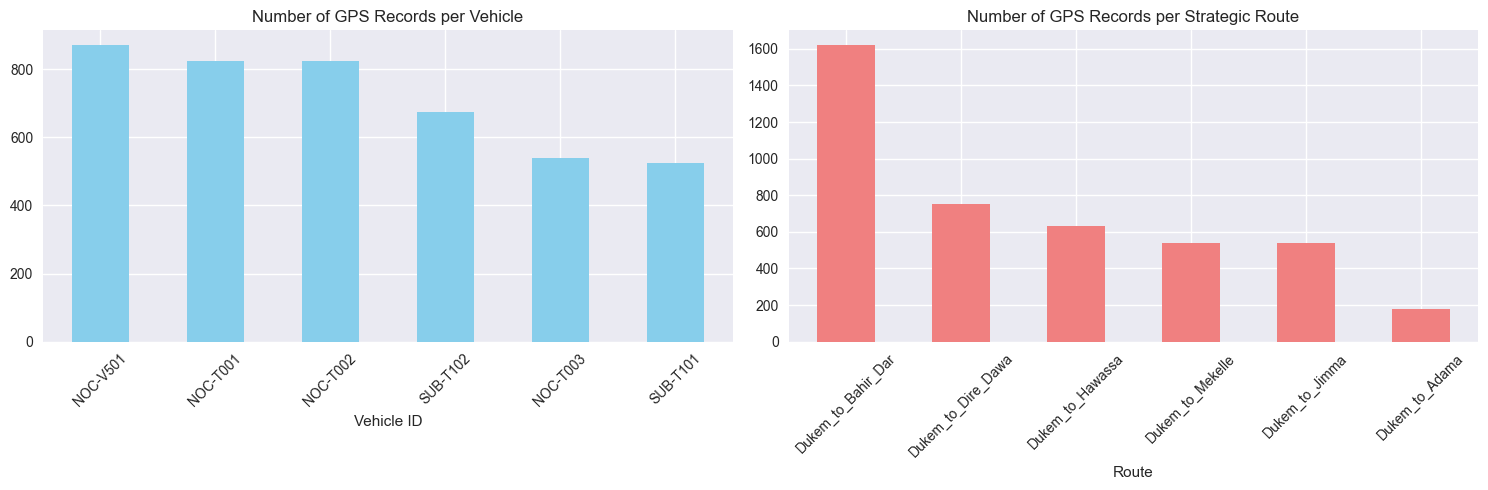

Route Distribution:
 route
Dukem_to_Bahir_Dar    1620
Dukem_to_Dire_Dawa     750
Dukem_to_Hawassa       630
Dukem_to_Mekelle       540
Dukem_to_Jimma         540
Dukem_to_Adama         180
Name: count, dtype: int64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df['vehicle_id'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Number of GPS Records per Vehicle')
axes[0].set_xlabel('Vehicle ID')
axes[0].tick_params(axis='x', rotation=45)

df['route'].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Number of GPS Records per Strategic Route')
axes[1].set_xlabel('Route')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Route Distribution:\n", df['route'].value_counts())

#### 3. Speed and Movement Patterns

C:\Users\tohiba\AppData\Local\Temp\ipykernel_7960\1345243100.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Is Moving')


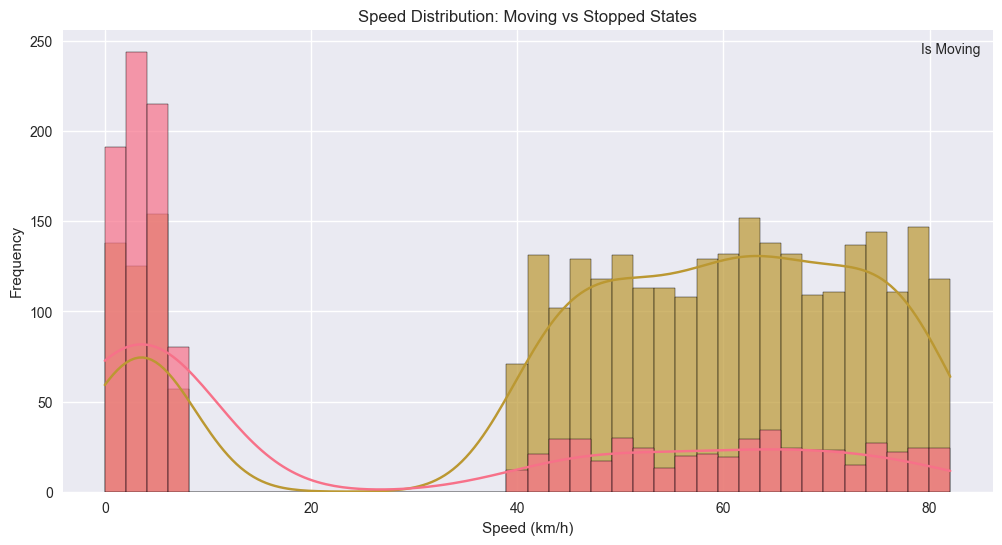


Average Speed by Vehicle:
vehicle_id
NOC-T001    43.7
NOC-T002    44.5
NOC-T003    42.9
NOC-V501    44.4
SUB-T101    47.6
SUB-T102    46.7
Name: speed_kmh, dtype: float64


In [9]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='speed_kmh', hue='is_moving', bins=40, kde=True, alpha=0.7)
plt.title('Speed Distribution: Moving vs Stopped States')
plt.xlabel('Speed (km/h)')
plt.ylabel('Frequency')
plt.legend(title='Is Moving')
plt.show()

print("\nAverage Speed by Vehicle:")
print(df.groupby('vehicle_id')['speed_kmh'].mean().round(1))

#### 4. Fuel Level Analysis (Critical for Theft Detection)

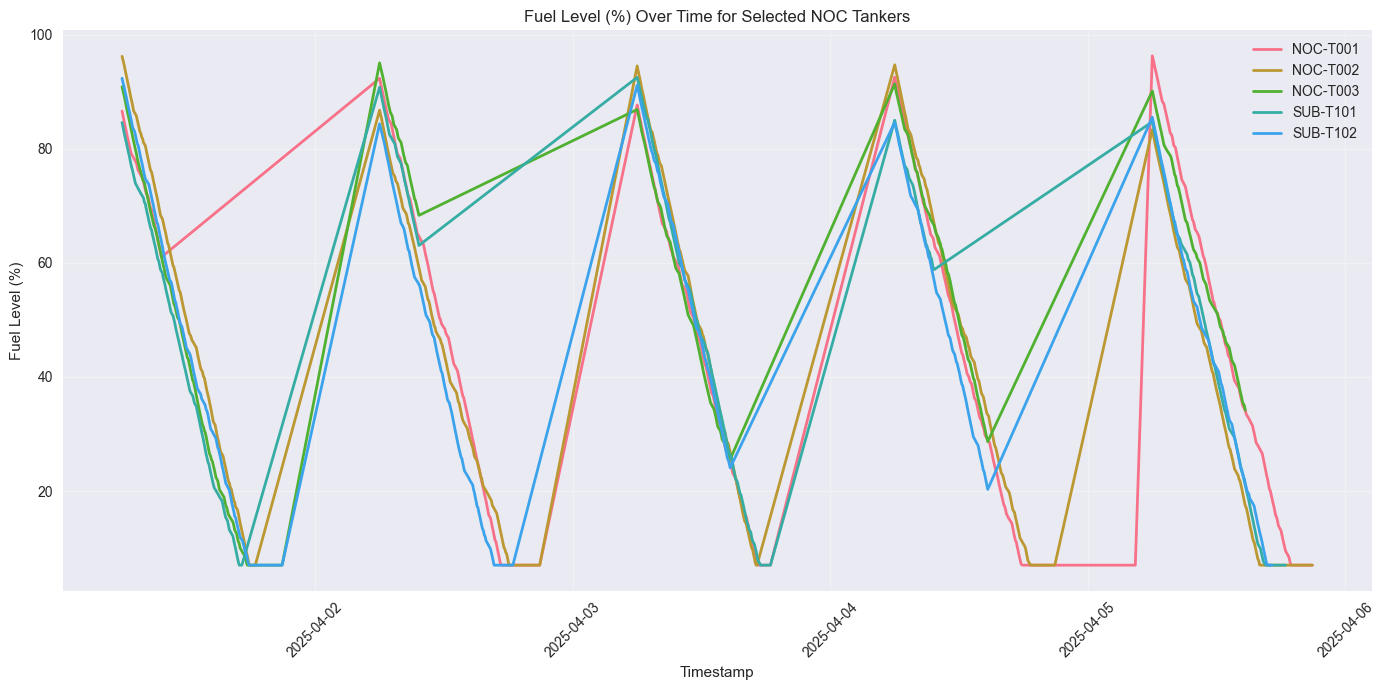


Fuel Level Statistics (Tankers only):


count    3390.00
mean       44.84
std        26.71
min         7.00
25%        20.02
50%        45.84
75%        68.20
max        96.32
Name: fuel_level_percent, dtype: float64

In [10]:
fuel_df = df[df['fuel_level_percent'].notna()].copy()

plt.figure(figsize=(14, 7))
for vehicle in sorted(fuel_df['vehicle_id'].unique())[:5]:
    veh_data = fuel_df[fuel_df['vehicle_id'] == vehicle]
    plt.plot(veh_data['timestamp'], veh_data['fuel_level_percent'], label=vehicle, linewidth=2)

plt.title('Fuel Level (%) Over Time for Selected NOC Tankers')
plt.xlabel('Timestamp')
plt.ylabel('Fuel Level (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nFuel Level Statistics (Tankers only):")
display(fuel_df['fuel_level_percent'].describe().round(2))

#### 5. Dispensing Valve Status Analysis (ECTS Key Feature)

In [11]:
print("Valve Status Distribution:")
print(df['valve_status'].value_counts())

open_events = df[df['valve_status'] == 'OPEN']
print(f"\nTotal OPEN valve events detected: {len(open_events)}")

if not open_events.empty:
    print("\nSample OPEN valve events (potential tampering/theft signals):")
    display(open_events[['timestamp', 'vehicle_id', 'speed_kmh', 'is_moving', 'route']].head())

Valve Status Distribution:
valve_status
CLOSED    4226
OPEN        34
Name: count, dtype: int64

Total OPEN valve events detected: 34

Sample OPEN valve events (potential tampering/theft signals):


,timestamp,vehicle_id,speed_kmh,is_moving,route
21,2025-04-01 07:45:00,NOC-T001,0.7,False,Dukem_to_Adama
22,2025-04-01 07:50:00,NOC-T001,6.1,False,Dukem_to_Adama
57,2025-04-02 07:00:00,NOC-T001,5.3,False,Dukem_to_Bahir_Dar
417,2025-04-04 09:30:00,NOC-T001,2.7,False,Dukem_to_Mekelle
472,2025-04-04 14:05:00,NOC-T001,3.9,False,Dukem_to_Mekelle


#### 6. Harsh Events and Device Health

In [12]:
print("Harsh Braking Events     :", df['harsh_braking'].sum())
print("Harsh Acceleration Events:", df['harsh_acceleration'].sum())
print("\nDevice Status Distribution:")
print(df['device_status'].value_counts())

Harsh Braking Events     : 111
Harsh Acceleration Events: 80

Device Status Distribution:
device_status
ONLINE     4170
OFFLINE      90
Name: count, dtype: int64
